# Investigating the structure factor 

In [1]:
import sys

sys.path.append("../../src")

import equilibrium_critical_correlations as eq

import kibble_zurek as kz

from common_imports import *

100%|██████████| 200/200 [00:13<00:00, 14.71it/s] 


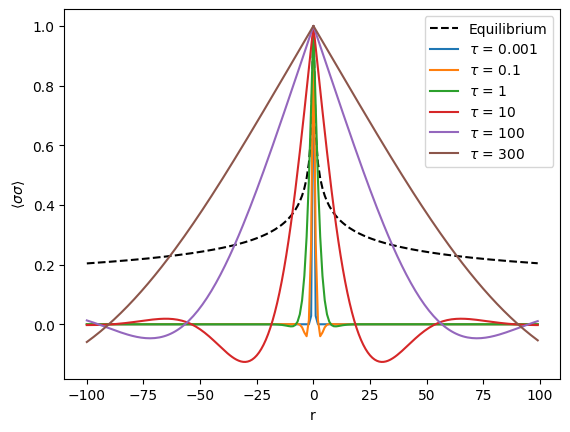

In [214]:
####
# Constants
####

taus = [0.001,.1,1, 10 , 100,300] # three is enough for now
L = 1000
states = [kz.state(L,tau,tau) for tau in taus] # L = 500 is enough, quench to g = 1

rs = np.arange(-100,100) #A wider range in R allows for more fidelity of structure factor

####
# 2 Point Functions
####

eq_xx = array([eq.sigma_general([0,r]) for r in tqdm(rs)]) #Equilibrium

quenched_xx = [ array([kz.sigma_general([0,r],s) for r in tqdm(rs)]) for s in states ]
plot(rs,eq_xx,"--k",label="Equilibrium")

for xx,tau in zip(quenched_xx,taus):
    plot(rs,xx,label=rf"$\tau$ = {tau}")

ylabel(r"$\langle \sigma \sigma \rangle$")
xlabel("r")
legend()

# Now let's Fourier Transform

/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, '$S(k)$')

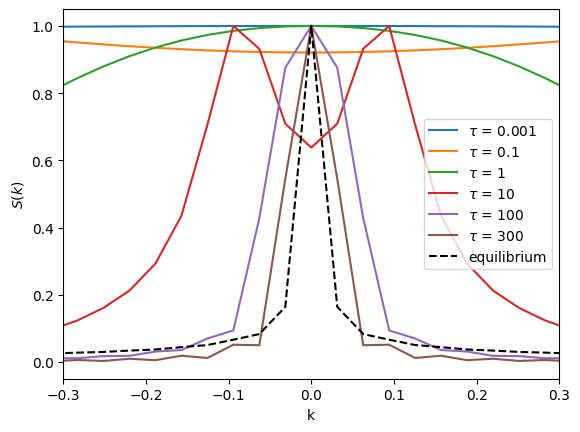

In [215]:
from numpy.fft import fft, fftfreq, fftshift
k = fftshift(fftfreq(len(rs),1))*2*pi
fourier_eq = fftshift(fft(eq_xx))
fourier_quenched = [fftshift(fft(xx)) for xx in quenched_xx]
for xx,tau in zip(fourier_quenched, taus):
    kzlength = np.sqrt(2.*pi*tau)
    plot(k, np.abs(xx)/np.max(np.abs(xx)),label= rf"$\tau$ = {tau}")
plot(k,np.abs(fourier_eq)/np.max(fourier_eq),"--k",label="equilibrium")

#plot(k*sqrt(tau)/2/pi,g(kzlength,k)/max(g(kzlength,k)),"--k")
xlim(-.3,.3)
#ylim(0,20)
#yscale("log")
legend()
xlabel("k")
ylabel(r"$S(k)$")

# Something Interesting 

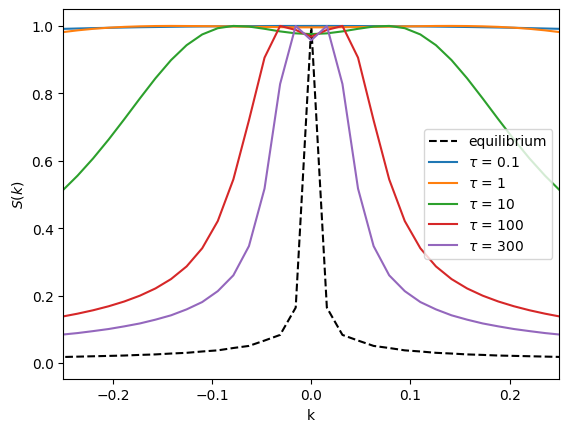

It is interesting how the structure factor of the correlators becomes increasing narrow and has a somewhat asymptotic limit as $k \to 0$.

Lets approximate this function as becoming perfectly "flat" at some value $k_c$. It obviously is true from the above graph that as $\tau \to \infty$ then $k_c \to 0$. 

$k_c \propto 1/\xi$ where $\xi$ is the correlation length which itself is related to the quench $\xi \propto \sqrt{\tau}$

Therefore $k_c \to 0$ is the same effect as saying that $\xi \to \infty$


Something very interesting that I'm not sure is right is this:

We approximate in the kibble zurek effect derivation that the integral of $$\int dk \text{stuff} \sim \int dk \cdot 1$$

Then evaluate this to a cutoff. I think what we can see is an increased "bowl" like growth in the middle, forming a minimum. If we integrate around this region, then $S(k) \sim S(0)+O(k^2)$ due to the fact that it is a local minimum. The region at which this approximation breaks down decreases with increasing $\tau$ as well. Even if you don't like that as an explanation, there's still the overall flat top of the function. It rapidly decreases from its maximum. This might be a good case to look into the integrals under these functions.

/tmp/ipykernel_6169/3910851647.py:5: RuntimeWarning: divide by zero encountered in power
  l**(1/8) * np.abs(x)**(-3/4))  # branch 2


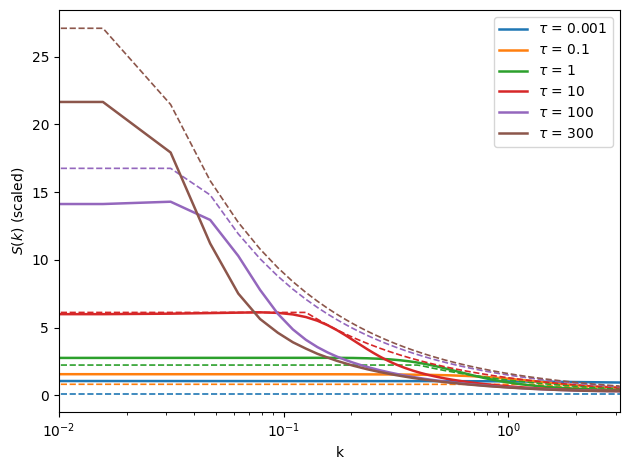

In [140]:

def g(l, x):
    lx = np.abs(l * x)
    result = np.where(lx < 1,
                      l**(7/8),            # branch 1
                      l**(1/8) * np.abs(x)**(-3/4))  # branch 2
    return result

# 10 highly distinct colors from tab10; repeat if more τs
palette = plt.cm.tab10.colors

for i, (xx, tau) in enumerate(zip(fourier_quenched, taus)):
    c = palette[i % len(palette)]
    kzlength = np.sqrt(2 * np.pi * tau)
    y1 = np.abs(xx)# / np.max(np.abs(xx))
    y2 = g(kzlength, k) #/ np.max(g(kzlength, k))

    plt.plot(k, y1, color=c, lw=1.8, label=rf"$\tau$ = {tau}")
    plt.plot(k, y2, "--", color=c, lw=1.2)

plt.xlabel("k")
xlim(0.01,3.14)
xscale("log")
plt.ylabel(r"$S(k)$ (scaled)")
plt.legend()
plt.tight_layout()



# Now let's see what we can get out of the Projectors

In [205]:
rs = np.arange(-100,100)
n = np.arange(1,7)
eq_P = [ array([eq.P_n_correlations(ni,r)-eq.P_n(ni)**2 for r in tqdm(rs)]) for ni in n]
# plot(rs,eq_xx,"--k",label="Equilibrium")

# for xx,tau in zip(quenched_xx,taus):
#     plot(rs,xx,label=rf"$\tau$ = {tau}")

# ylabel(r"$\langle \sigma \sigma \rangle$")
# xlabel("r")
# legend()

100%|██████████| 200/200 [01:44<00:00,  1.92it/s]


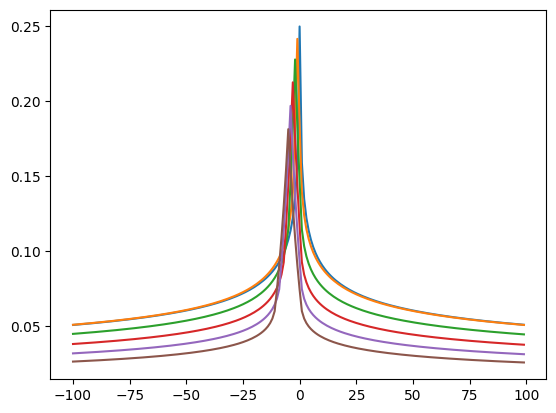

In [207]:
for p in eq_P:
    plot(rs,p)

Text(0, 0.5, '$S(k)$')

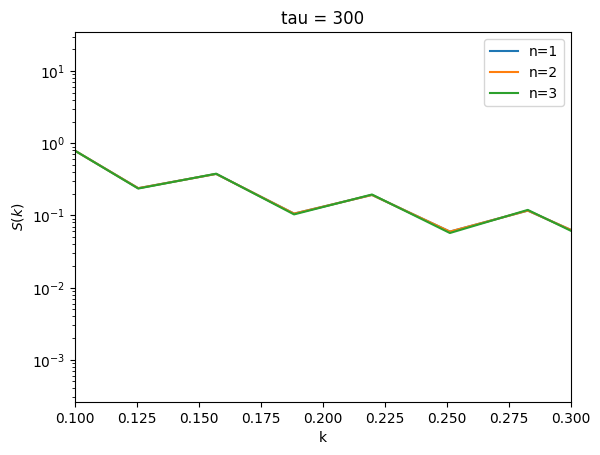

In [220]:
from numpy.fft import fft, fftfreq, fftshift
k = fftshift(fftfreq(len(rs),1))*2*pi
fourier_Pp = [fftshift(fft(p)) for p in eq_P]
fourier_P1 = [fftshift(fft(p)) for p in quenched_P3]

for i,p in enumerate(fourier_P1):
    kzlength = np.sqrt(2.*pi*tau)
 #   plot(k, np.abs(p)/np.max(np.abs(p)))
    plot(k, np.abs(p),label=f"n={i+1}")
title(f"tau = {taus[-1]}")

#plot(k,np.abs(fourier_eq)/np.max(fourier_eq),"--k",label="equilibrium")

#plot(k*sqrt(tau)/2/pi,g(kzlength,k)/max(g(kzlength,k)),"--k")
xlim(0.1,.3)
#ylim(0,20)
yscale("log")
legend()
xlabel("k")
ylabel(r"$S(k)$")

In [174]:
rs = np.arange(-100,100)
quenched_P1 = [ array([kz.P_n_correlations(1,r,s)-kz.P_n(1,s)**2 for r in tqdm(rs)]) for s in states ]
# plot(rs,eq_xx,"--k",label="Equilibrium")


  0%|          | 0/200 [00:00<?, ?it/s]/home/kristian/Desktop/Subsystem Loschmidt Echo/subsystem_loschmidt_echo/scripts/October /../../src/kibble_zurek.py:172: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
100%|██████████| 200/200 [00:13<00:00, 14.62it/s] 


In [216]:

rs = np.arange(-100,100)
def compute_quenched_P(rs, s, n):
    return np.array([kz.P_n_correlations(n, r, s) - kz.P_n(n, s)**2 for r in tqdm(rs)])

quenched_P3 = [compute_quenched_P(rs,states[-1],ni) for ni in np.arange(1,4)] 

100%|██████████| 200/200 [02:44<00:00,  1.21it/s]


(-5.0, 2.0)

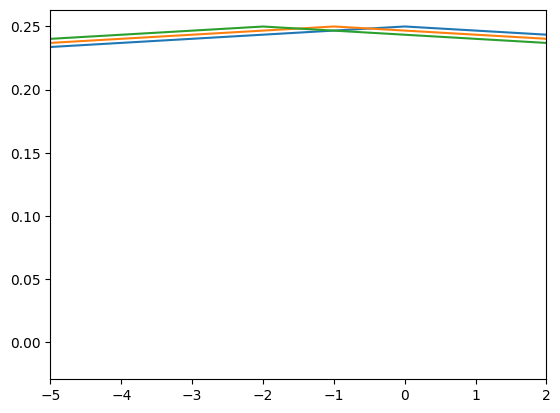

In [217]:
for p in quenched_P3:
    plot(rs,p)
xlim(-5,2)

We can see that the structure factor of the strings is actually narrower for larger ones 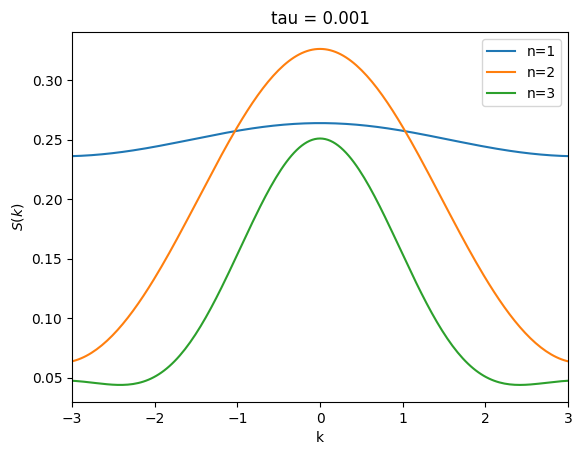

its almost always actually narrower 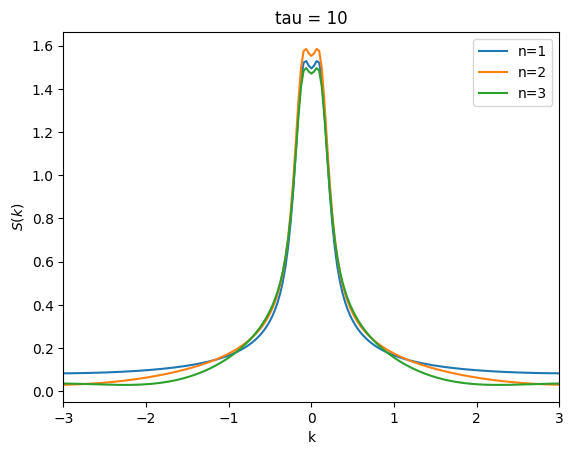

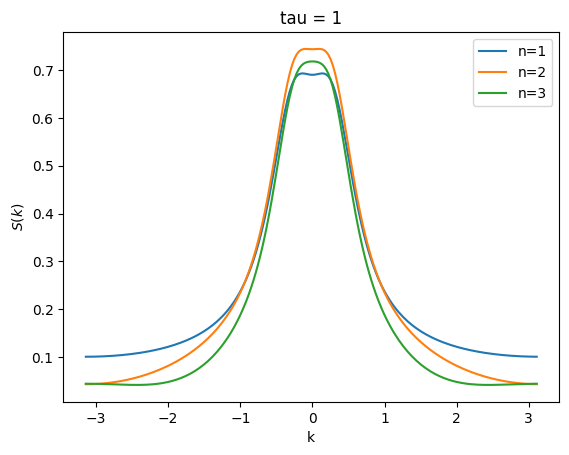

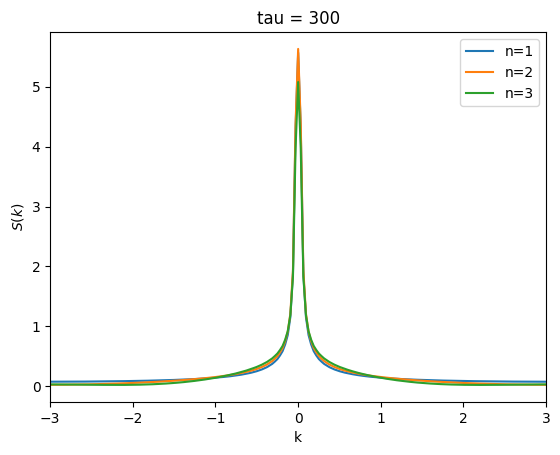